In [17]:
# ---------------------------------------------------------------------------
# Imports: Core AutoGen components and utilities
# ---------------------------------------------------------------------------
import autogen
from autogen import AssistantAgent, UserProxyAgent
from autogen.coding import LocalCommandLineCodeExecutor
from pathlib import Path
from IPython.display import Image, Markdown
from dotenv import load_dotenv
import os

In [18]:
load_dotenv()  # Loads .env from the current directory (or parent directories)

True

In [19]:
# Step 2a: Load model configuration from CONFIG_LIST.json using the modern LLMConfig API.
# Keep this file out of source control; use .env or env vars for the actual API key.
llm_config_obj = autogen.LLMConfig.from_json(path="CONFIG_LIST.json")
config_list = llm_config_obj.config_list

# Optional: Filter config_list by model name
# Example: Filter to use only "llama-3.3-70b-versatile"
# config_list = [config for config in config_list if config.get("model") == "llama-3.3-70b-versatile"]

# Or filter to use only "openai/gpt-oss-120b"
config_list = [config for config in config_list if config.get("model") == "openai/gpt-oss-120b"]

# Or filter by partial model name match
# config_list = [config for config in config_list if "llama" in config.get("model", "").lower()]

In [20]:
# Create a directory for code execution
work_dir = Path("coding_workspace")
work_dir.mkdir(exist_ok=True)

# Define the code executor
code_executor = LocalCommandLineCodeExecutor(
    work_dir=work_dir,  # Where files are saved
    timeout=120         # Execution timeout in seconds
)

In [21]:
# Agent that writes code
coder = AssistantAgent(
    name="python_expert",
    llm_config={"config_list": config_list},
    system_message="""You are a helpful AI assistant specialized in Python programming.
    When asked to solve a problem, write Python code to solve it.
    Wrap code in markdown blocks like ```python ... ```.
    The user will execute the code and report the result.
    If there is an error, fix the code and output the full corrected version.
    When the task is done, reply with 'TERMINATE'."""
)

In [22]:
# Agent that executes code
user_proxy = UserProxyAgent(
    name="executor_user",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=10,
    is_termination_msg=lambda x: x.get("content", "").strip().endswith("TERMINATE"),
    code_execution_config={"executor": code_executor}
)

In [23]:
# Task description
task = """
Plot a chart comparing Tesla (TSLA) and Nvidia (NVDA) stock prices for the last 6 months.
Save the plot as 'stock_comparison.png'.
Make sure to install yfinance and matplotlib if needed.
"""

user_proxy.initiate_chat(coder, message=task)

executor_user (to python_expert):


Plot a chart comparing Tesla (TSLA) and Nvidia (NVDA) stock prices for the last 6 months.
Save the plot as 'stock_comparison.png'.
Make sure to install yfinance and matplotlib if needed.


--------------------------------------------------------------------------------
python_expert (to executor_user):

Here is a self‑contained Python script that will:

1. Install the required packages (`yfinance` and `matplotlib`) if they are not already present.  
2. Download the daily adjusted close prices for Tesla (TSLA) and Nvidia (NVDA) for the last 6 months.  
3. Plot both time series on the same chart.  
4. Save the figure as **`stock_comparison.png`** in the current working directory.

```python
# stock_comparison.py
import subprocess
import sys

# ---------- Helper to install missing packages ----------
def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Try importing; if it fails, install the package t

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/.venv/lib/python3.13/site-packages/autogen/oai/groq.py:317: UserWarning: Cost calculation not available for model openai/gpt-oss-120b
  warnings.warn(f"Cost calculation not available for model {model}", UserWarning)


ChatResult(chat_id=149163149172098741099521358421794539410, chat_history=[{'content': "\nPlot a chart comparing Tesla (TSLA) and Nvidia (NVDA) stock prices for the last 6 months.\nSave the plot as 'stock_comparison.png'.\nMake sure to install yfinance and matplotlib if needed.\n", 'role': 'assistant', 'name': 'executor_user'}, {'content': 'Here is a self‑contained Python script that will:\n\n1. Install the required packages (`yfinance` and `matplotlib`) if they are not already present.  \n2. Download the daily adjusted close prices for Tesla (TSLA) and Nvidia (NVDA) for the last 6\u202fmonths.  \n3. Plot both time series on the same chart.  \n4. Save the figure as **`stock_comparison.png`** in the current working directory.\n\n```python\n# stock_comparison.py\nimport subprocess\nimport sys\n\n# ---------- Helper to install missing packages ----------\ndef pip_install(package):\n    subprocess.check_call([sys.executable, "-m", "pip", "install", package])\n\n# Try importing; if it fails,

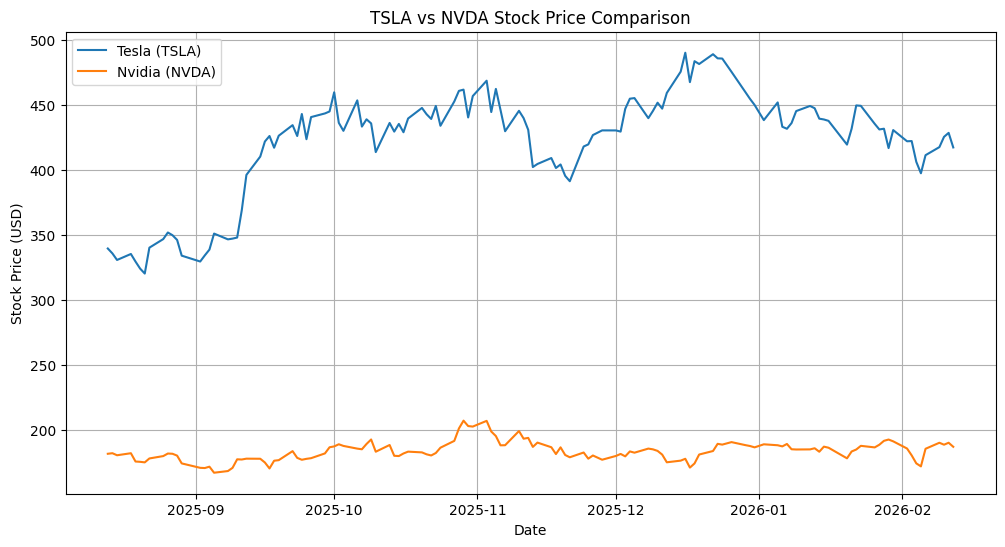

In [24]:
# ---------------------------------------------------------------------------
# Display the chart produced by the agent (saved in the "coding" work directory)
# ---------------------------------------------------------------------------
Image("coding_workspace/stock_comparison.png")

### Research report generation

The same assistant + user proxy can handle more involved tasks. In this example, the agent is asked to fetch papers (e.g. from arXiv), summarize them, and write a single Markdown report. The conversation may take several turns (install deps, run scripts, retry on errors). When running in a notebook you may need to press Enter to allow auto-reply or type `exit` to stop.

In [ ]:
# Wrapper to send a natural-language task to the assistant. The user proxy
# starts the chat; the assistant may respond with code; the proxy executes it
# and sends results back until the task is done (or you type 'exit').
# Agent that writes code
coder = AssistantAgent(
    name="python_expert",
    llm_config={"config_list": config_list},
    system_message="""You are a helpful AI assistant specialized in Python programming.
    When asked to solve a problem, write Python code to solve it.
    Wrap code in markdown blocks like ```python ... ```.
    The user will execute the code and report the result.
    If there is an error, fix the code and output the full corrected version.
    When the task is done, reply with 'TERMINATE'."""
)
# Agent that executes code
user_proxy = UserProxyAgent(
    name="executor_user",
    human_input_mode="TERMINATE",
    max_consecutive_auto_reply=5,
    # is_termination_msg=lambda x: x.get("content", "").strip().endswith("TERMINATE"),
    code_execution_config={"executor": code_executor}
)

def execute_agent(prompt: str):
    """Send a task to the assistant via the user proxy."""
    return user_proxy.initiate_chat(coder, message=prompt)

# Example 1: Data + plotting. The assistant will typically suggest a Python script
# (e.g. using yfinance + matplotlib), the proxy runs it in the "coding" folder,
# and the plot is saved as stock_price_change.png there.
execute_agent(
    """Fetch 2 papers about using small language models and
    summarize them into a one single research report file named research-small-llms.md. Use arXiv API to fetch the papers and provide the final report in Markdown format."""
)

executor_user (to python_expert):

Fetch 2 papers about using small language models and
    summarize them into a one single research report file named research-small-llms.md. Use arXiv API to fetch the papers and provide the final report in Markdown format.

--------------------------------------------------------------------------------
python_expert (to executor_user):

Below is a self‑contained Python script that

1. Queries the arXiv API for papers that mention **small language models** (or similar terms) in their title or abstract.  
2. Retrieves the two most recent results.  
3. Builds a concise research report in Markdown format that includes for each paper: title, authors, abstract, a short “Key Points” bullet list extracted from the abstract (very simple heuristic), and a link to the PDF.  
4. Writes the report to a file called **`research-small-llms.md`** in the current working directory.

You can run the script as‑is (Python 3.8+ required). It only depends on the standard l

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/.venv/lib/python3.13/site-packages/autogen/oai/groq.py:317: UserWarning: Cost calculation not available for model openai/gpt-oss-120b
  warnings.warn(f"Cost calculation not available for model {model}", UserWarning)


executor_user (to python_expert):

exitcode: 1 (execution failed)
Code output: Traceback (most recent call last):
  File "/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/autogen-workshop/coding_workspace/tmp_code_2a6df5ccede480c90990070bd7019288.py", line 137, in <module>
    main()
    ~~~~^^
  File "/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/autogen-workshop/coding_workspace/tmp_code_2a6df5ccede480c90990070bd7019288.py", line 124, in main
    entries = query_arxiv(query, max_results=5)
  File "/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/autogen-workshop/coding_workspace/tmp_code_2a6df5ccede480c90990070bd7019288.py", line 43, in query_arxiv
    raise RuntimeError(f"arXiv API request failed with status {response.get('status')}")
RuntimeError: arXiv API request failed with status 301
Fetching from arXiv: http://export.arxiv.org/api/query?search_query=all:%22small+language+model%22

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/.venv/lib/python3.13/site-packages/autogen/oai/groq.py:317: UserWarning: Cost calculation not available for model openai/gpt-oss-120b
  warnings.warn(f"Cost calculation not available for model {model}", UserWarning)


executor_user (to python_expert):

exitcode: 2 (execution failed)
Code output: Fetching from arXiv: https://export.arxiv.org/api/query?search_query=all:%22small+language+model%22+OR+%22compact+language+model%22+OR+%22efficient+language+model%22+OR+%22lightweight+language+model%22&start=0&max_results=5&sortBy=submittedDate&sortOrder=descending

✅ Report written to research-small-llms.md
/opt/homebrew/Cellar/python@3.13/3.13.11/Frameworks/Python.framework/Versions/3.13/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/autogen-workshop/coding_workspace/fetch_small_llms.py': [Errno 2] No such file or directory


--------------------------------------------------------------------------------
python_expert (to executor_user):

The script actually succeeded – it fetched the two most recent arXiv papers that mention *small/compact/efficient language models* and created the file **`research-small-llms.m

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/.venv/lib/python3.13/site-packages/autogen/oai/groq.py:317: UserWarning: Cost calculation not available for model openai/gpt-oss-120b
  warnings.warn(f"Cost calculation not available for model {model}", UserWarning)


python_expert (to executor_user):

The script itself ran successfully and wrote **`research-small-llms.md`**.  
The error you see now (`can't open file … fetch_small_llms.py: [Errno 2]`) simply means the Python interpreter was asked to execute a file that does not exist in the current folder.

Below are two easy ways to get the report without having to hunt down a missing file:

---

## 1️⃣ Quick‑run‑in‑one‑line (no separate file needed)

Open a terminal in the folder where you want the markdown report and paste the whole command exactly as shown:

```bash
python - <<'PY'
import sys, subprocess, importlib.util, textwrap, re
from urllib.parse import quote_plus

# --------------------------------------------------------------
# Ensure feedparser is installed
# --------------------------------------------------------------
if importlib.util.find_spec("feedparser") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "feedparser"])
import feedparser

# --------------

/Users/sourav.banerjee/Documents/Codebases/2. AI ENGINEERING/Autogen_Demystified/.venv/lib/python3.13/site-packages/autogen/oai/groq.py:317: UserWarning: Cost calculation not available for model openai/gpt-oss-120b
  warnings.warn(f"Cost calculation not available for model {model}", UserWarning)


executor_user (to python_expert):

exitcode: 1 (execution failed)
Code output: Fetching: https://export.arxiv.org/api/query?search_query=all:%22small+language+model%22+OR+%22compact+language+model%22+OR+%22efficient+language+model%22+OR+%22lightweight+language+model%22&start=0&max_results=5&sortBy=submittedDate&sortOrder=descending

✅ Report written to research-small-llms.md

unknown language 

--------------------------------------------------------------------------------


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jz69x0mzerh8ts9zknk0am8n` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8256, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}